**Aggregation Model**

In [1]:
## DATA AND PACKAGE IMPORT 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace

## import data from particle concentration, backscatter, fluorescence
part_conc_490 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="4903659_binned_small_removed").iloc[:, 1:]
part_conc_699 = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="6990636_binned_small_removed").iloc[:, 1:]

'''

bbp_490 = pd.read_excel("BBP_binned.xlsx", sheet_name="4903659")
bbp_699 = pd.read_excel("BBP_binned.xlsx", sheet_name="6990636")

chla_fluor_490 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="4903659")
chla_fluor_699 = pd.read_excel("Chl_fluor_binned.xlsx", sheet_name="6990636")

'''

temp_490 = pd.read_excel("Temp_binned.xlsx", sheet_name="4903659")
temp_699 = pd.read_excel("Temp_binned.xlsx", sheet_name="6990636")

sal_490 = pd.read_excel("Sal_binned.xlsx", sheet_name="4903659")
sal_699 = pd.read_excel("Sal_binned.xlsx", sheet_name="6990636")

# define depth array, time array (profiles)
depth = part_conc_490["depth_bin"].iloc[:60]
time_490 = pd.Series(range(1, 45))
time_699 = pd.Series(range(1, 78))            # probably won't use all of these profiles
#size_classes = part_conc_490.columns.to_numpy()[1:]
sizes = np.array([102,128,161,203,256,323,406,512,645,813,1020,1290,1630,2050,2580])

In [2]:
## SEPARATING FLOAT 490 PROFILES INTO INDIVIDUAL UVP6 DATAFRAMES 
# this does not contain backscatter or fluorescence yet

# Create container object
f490 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_490.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_490)]

skip_numbers = {13, 19}

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_490.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f490, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
#f490.p7.to_excel("f490.p7.xlsx", index=False)




## tada, doing the same with 6990636 
# this does not contain backscatter or fluorescence yet

# Create container object
f699 = SimpleNamespace()

# Identify blank rows (all NaN) and get indices
blank_rows = part_conc_699.isna().all(axis=1)
split_points = blank_rows[blank_rows].index.tolist()

# Add start and end boundaries
split_points = [-1] + split_points + [len(part_conc_699)]

skip_numbers = {4, 17, 29, 53, 72}   # works too 11/6

section_number = 1

for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]

    # Extract the block
    block = part_conc_699.iloc[start:end].reset_index(drop=True)

    #block["bbp"] = bbp_490.iloc[:len(block), section_number - 1].values
    #block["chla"] = chla_fluor_490.iloc[:len(block), section_number - 1].values

# Skip truly empty blocks
    if len(block) == 0:
        continue
    
# Skip numbers before assigning
    while section_number in skip_numbers:
        section_number += 1

    attr_name = f"p{section_number}"
    setattr(f699, attr_name, block)

    section_number += 1

# Export an individual profile here (in case one needs checking!)
# f699.p8.to_excel("f699.p8.xlsx", index=False)


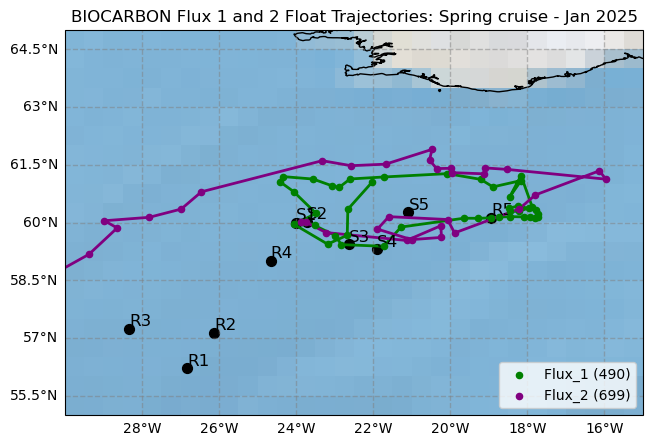

'"\n# Plotting particle concentration data with time\nfig, ax = plt.subplots()\n\n# Particle size 102 data for 490\n# time = (float numbers/dates)\n# y = (data from all profiles for f490)\n\n# Create figure and axes\nfig, ax = plt.subplots()\n\n# Plot the data\nax.plot(x, y, marker=\'o\')\nax.set_xlabel("X values")\nax.set_ylabel("Y values")\nax.set_title("Simple Line Plot")\nax.grid(True)\nplt.show()\n\n'

In [21]:
## Creating Figures for Presentation

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Argo float trajectories figure

float_data = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data")
lat = float_data.loc[:,"latitude"]
lon = float_data.loc[:,"longitude"]
lat.drop_duplicates(inplace = True), lon.drop_duplicates(inplace = True)

# index of first value of 699 is 44
lat_490 = lat[:44]
lon_490 = lon[:44]
lat_699 = lat[44:]
lon_699 = lon[44:]

# plotting on map

# Create a figure with a map projection
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.OCEAN) #facecolor='lightblue')
ax.stock_img()

gl = ax.gridlines(draw_labels=True,
                  linewidth=1,
                  color='gray',
                  alpha=0.5,
                  linestyle='--')

gl.top_labels = False
gl.right_labels = False

s1_lat = 60.00016
s1_lon = -24.0004
s2_lat = 60.01922
s2_lon = -23.7194 
s3_lat = 59.43715
s3_lon = -22.6379 
s4_lat = 59.30469
s4_lon = -21.9108 
s5_lat = 60.26593
s5_lon = -21.0875

r1_lat = 56.21604
r1_lon = -26.8302
r2_lat = 57.12564
r2_lon = -26.1376
r3_lat = 57.23220
r3_lon = -28.3443
r4_lat = 59.01343
r4_lon = -24.6674 
r5_lat = 60.12009
r5_lon = -18.9309


# Plot the points
ax.scatter(lon_490, lat_490, color='green', s=20, label="Flux_1 (490)", transform=ccrs.PlateCarree(), zorder=5)
ax.scatter(lon_699, lat_699, color='purple', s=20, label="Flux_2 (699)", transform=ccrs.PlateCarree(), zorder=5)

ax.legend(loc='lower right')

ax.scatter(s1_lon, s1_lat, color='black', s=50, label="S1", transform=ccrs.PlateCarree())
ax.scatter(s2_lon, s2_lat, color='black', s=50, label="S2", transform=ccrs.PlateCarree())
ax.scatter(s3_lon, s3_lat, color='black', s=50, label="S3", transform=ccrs.PlateCarree())
ax.scatter(s4_lon, s4_lat, color='black', s=50, label="S4", transform=ccrs.PlateCarree())
ax.scatter(s5_lon, s5_lat, color='black', s=50, label="S5", transform=ccrs.PlateCarree())

ax.scatter(r1_lon, r1_lat, color='black', s=50, label="R1", transform=ccrs.PlateCarree())
ax.scatter(r2_lon, r2_lat, color='black', s=50, label="R2", transform=ccrs.PlateCarree())
ax.scatter(r3_lon, r3_lat, color='black', s=50, label="R3", transform=ccrs.PlateCarree())
ax.scatter(r4_lon, r4_lat, color='black', s=50, label="R4", transform=ccrs.PlateCarree())
ax.scatter(r5_lon, r5_lat, color='black', s=50, label="R5", transform=ccrs.PlateCarree())


# Draw lines connecting points
ax.plot(lon_490, lat_490, color='green', linewidth=2, transform=ccrs.PlateCarree())
ax.plot(lon_699, lat_699, color='purple', linewidth=2, transform=ccrs.PlateCarree())

# Set extent (optional: zoom to data)
ax.set_extent([
    -30, -15,
    55, 65
])

ax.text(s1_lon, s1_lat, "S1", fontsize=12, ha='left', va='bottom')
ax.text(s2_lon, s2_lat, "S2", fontsize=12, ha='left', va='bottom')
ax.text(s3_lon, s3_lat, "S3", fontsize=12, ha='left', va='bottom')
ax.text(s4_lon, s4_lat, "S4", fontsize=12, ha='left', va='bottom')
ax.text(s5_lon, s5_lat, "S5", fontsize=12, ha='left', va='bottom')
ax.text(r1_lon, r1_lat, "R1", fontsize=12, ha='left', va='bottom')
ax.text(r2_lon, r2_lat, "R2", fontsize=12, ha='left', va='bottom')
ax.text(r3_lon, r3_lat, "R3", fontsize=12, ha='left', va='bottom')
ax.text(r4_lon, r4_lat, "R4", fontsize=12, ha='left', va='bottom')
ax.text(r5_lon, r5_lat, "R5", fontsize=12, ha='left', va='bottom')


plt.title("BIOCARBON Flux 1 and 2 Float Trajectories: Spring cruise - Jan 2025")
plt.show()
                           
# lost my graph for the powerpoint - rewrite code if needed?

""""
# Plotting particle concentration data with time
fig, ax = plt.subplots()

# Particle size 102 data for 490
# time = (float numbers/dates)
# y = (data from all profiles for f490)

# Create figure and axes
fig, ax = plt.subplots()

# Plot the data
ax.plot(x, y, marker='o')
ax.set_xlabel("X values")
ax.set_ylabel("Y values")
ax.set_title("Simple Line Plot")
ax.grid(True)
plt.show()

"""

C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData\Local\Temp\ipykernel_23104\1211076190.py:72: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
C:\Users\steph\AppData

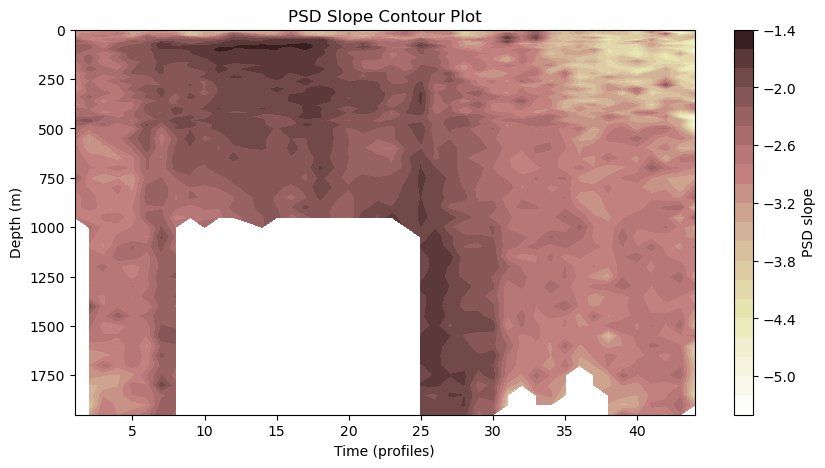

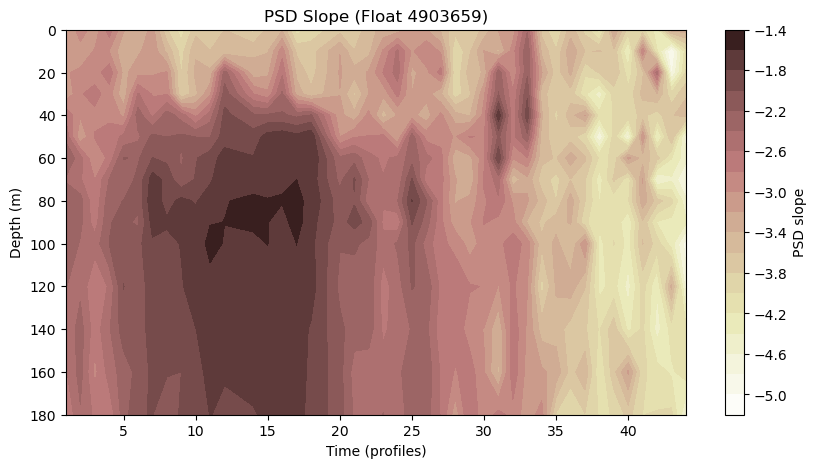

In [3]:
# BIOCARBON playing around
 

# # define parameters of particle size class, fluor, backscatter (maybe do a backscatter POC relationship curve conversion?), eventually turbulence


# input equations for particle dynamics - two size class approach?

# what float profiles match closest with the station locations?

# calculate PSD for each depth across size bins

def psd_slope(sizes, concentrations, use_cumulative=False):
    """
    Calculate PSD slope in log-log space.
    """

    import pandas as pd

    # Convert to pandas Series
    sizes = pd.Series(sizes).reset_index(drop=True)
    concentrations = pd.Series(concentrations).reset_index(drop=True)

    # Combine into DataFrame for easier handling
    df = pd.DataFrame({
        "sizes": sizes,
        "concentrations": concentrations
        })

    
    # Force numeric
    df["sizes"] = pd.to_numeric(df["sizes"], errors='coerce')
    df["concentrations"] = pd.to_numeric(df["concentrations"], errors='coerce')

    # Drop NaNs
    df = df.dropna()

    # Sort by size
    df = df.sort_values("sizes")

    # Normalize concentrations
    df["concentrations"] = df["concentrations"] / df["concentrations"].sum()

    # Optional cumulative
    if use_cumulative:
        df["concentrations"] = df["concentrations"].cumsum()

    # Remove invalid values for log
    df = df[(df["sizes"] > 0) & (df["concentrations"] > 0)]

    # Log transform (SAFE in pandas)
    df["log_sizes"] = df["sizes"].apply(lambda x: np.nan if x <= 0 else np.log10(x))
    df["log_conc"] = df["concentrations"].apply(lambda x: np.nan if x <= 0 else np.log10(x))


    df = df.dropna()

    # Linear regression using pandas (no np.polyfit)
    # slope = covariance(x,y) / variance(x)
    x = df["log_sizes"]
    y = df["log_conc"]

    slope = x.cov(y) / x.var()
    intercept = y.mean() - slope * x.mean()

    # Predicted values
    predicted = slope * x + intercept

    # R² calculation
    ss_res = ((y - predicted) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r_squared = 1 - (ss_res / ss_tot)

    return {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_squared
    }

test_p1_f490 = pd.to_numeric(f490.p1.iloc[0, 1:], errors='coerce')
#print(psd_slope(size_classes, test_p1_f490))



# Find all .pX attributes
p_keys = [key for key in f490.__dict__.keys() if key.startswith("p")]

all_results = {}

for p_key in p_keys:
    p_df = getattr(f490, p_key)

    # Extract sizes (column headers, skip first column)
    sizes = pd.to_numeric(p_df.columns[1:], errors='coerce')

    slopes = []

    # Loop through ALL rows (depth bins)
    for row in range(p_df.shape[0]):
        concentrations = pd.to_numeric(p_df.iloc[row, 1:], errors='coerce')

        res = psd_slope(sizes, concentrations)
        slopes.append(res["slope"])

    # Store results for this dataset
    all_results[p_key] = slopes

# Create final DataFrame
slope_df = pd.DataFrame(all_results)


# just need to plot and have a look
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth, errors="coerce").to_numpy()

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y)

# Z values
Z = slope_df.to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope Contour Plot")

# Invert depth axis (common in oceanography)
plt.gca().invert_yaxis()

plt.show()



# Plot from first 200 m 
fig, ax = plt.subplots(figsize=(10, 5))

# Convert columns ("p1", "p2", ...) → numbers
X = [int(col.replace("p", "")) for col in slope_df.columns]

# Depth (rows)
Y = pd.to_numeric(depth, errors="coerce").to_numpy()
Y_shallow = Y[0:15]

# Meshgrid
X_grid, Y_grid = np.meshgrid(X, Y_shallow)     # specify range that is length of Y and X

# Z values
Z = slope_df.iloc[:15, :].to_numpy(dtype=float)

contour = plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='pink_r')

plt.plot()
plt.colorbar(contour, label="PSD slope")
plt.xlabel("Time (profiles)")
plt.ylabel("Depth (m)")
plt.title("PSD Slope (Float 4903659)")

# Invert depth axis
plt.gca().invert_yaxis()

plt.show()


**The Old Code Graveyard (where code can be useful but sits here in storage):**

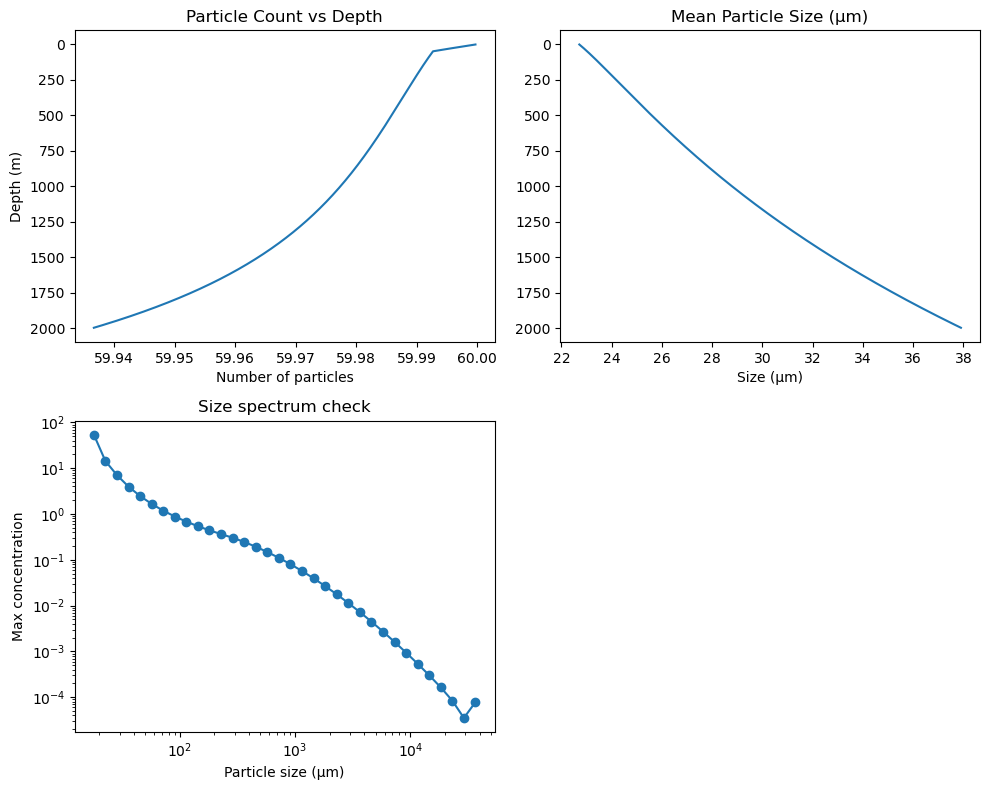

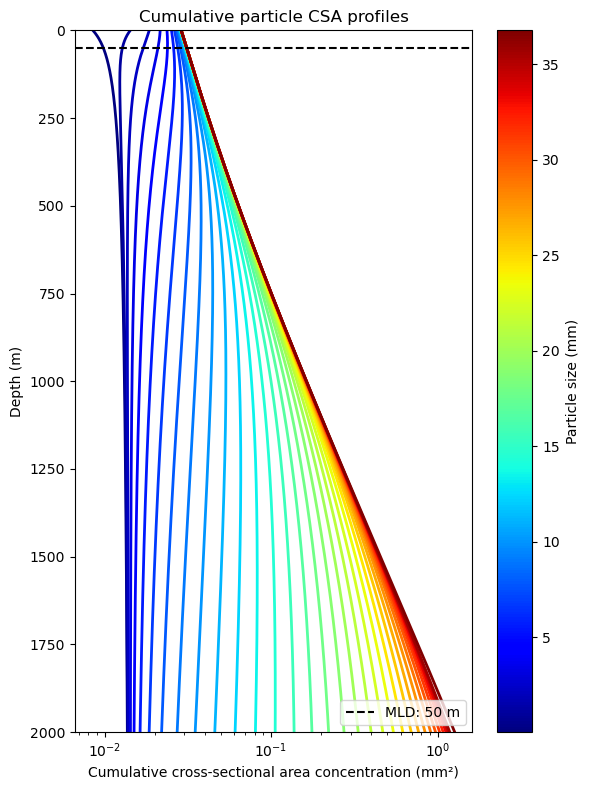

In [ ]:
# ------------------------------
# CREATES SIZE BINS
# ------------------------------
size_bounds = 2 ** np.arange(4, 15 + 1/3, 1/3)    # starting size 16 um, up to 40 mm, in 1/3 log power increments
size_bins = np.sqrt(size_bounds[:-1] * size_bounds[1:])  # bin centres

radius = size_bins / 2.0  # microns               
radius_m = radius * 1e-6                          # converts radius to m for sinking velocity

n_bins = len(size_bins)                           # 35 size classes

# ---------------------------------------------------
# INITIAL PARTICLE NUMBERS, DISTRIBUTION + PROPERTIES
# ---------------------------------------------------
N0 = 60                                        # starting cross-sectional area of particles

# all particles start in smallest bin
#C = np.zeros(n_bins)
#C[0] = N0

# power-law slope for starting particle distribution
slope = 3.5                                       # n(D) ~ D^-slope, where slope is the exponent of the power-law distribution
# generate power-law distribution
C = (size_bins / size_bins[0]) ** (-slope)
# scale to total number of particles
C = C / np.sum(C) * N0


# -------------------------------------------------------
# INITIAL CSA DISTRIBUTION (for using instead of numbers)
# -------------------------------------------------------

'''
N0 = 30000

M0 = 60

slope = 3.5
Df = 2.0

particle_mass = size_bins**Df

M = (size_bins / size_bins[0]) ** (-slope)
M = M / np.sum(M) * M0
'''

# Mass
"""
particle_mass = size_bins**Df                                       # particle mass of each size bin = size^Df, currently assuming a constant Df between particles
M = N * particle_mass                                               # number of particles in each size class * mass of each size bin (total mass per bin)
"""


# Parameters
Df = 2  # fractal dimension                
rho_f = 1025    # seawater density (kg/m^3)                      
mu = 1e-3       # viscosity (Pa·s)
g = 9.81        # force due to gravity
stick = 0.2

# Density based on fractal dimension
def particle_density(r):
    # reference radius (smallest particle)
    r0 = radius_m[0]
    rho0 = 1050   # density at smallest size

    rho_eff = rho0 * (r / r0)**(Df - 3)

    return max(rho_eff, rho_f + 1)   # prevent particle density < seawater density


# Turbulent shear values                       ## will adapt shear values above MLD and another below MLD, this might need to be included as W m2 or similar
surface_G = 10.0
deep_G = 1.0
MLD = 50  # mixed layer depth (m)    # adapt so this can be read from the relevant float profile/whichever is selected as reference

# ---------------------------------------------------
# DEFINE KERNELS
# ---------------------------------------------------

# experimenting with fractal dimension scaling for settling velocity
def settling_velocity(r):
    rho_eff = particle_density(r)
    return (2/9) * (rho_eff - rho_f) * g * r**2 / mu

def shear_rate(depth):
    return surface_G if depth < MLD else deep_G

def jackson_kernel(r1, r2, depth):
    G = shear_rate(depth)
    
    beta_shear = 1.3 * G * (r1 + r2)**3     # shear aggregation
    
    w1 = settling_velocity(r1)
    w2 = settling_velocity(r2)
    beta_settle = np.pi * (r1 + r2)**2 * abs(w1 - w2)  # diff. settling

    return beta_shear + beta_settle         # total aggregation
    # can add brownian motion if we think it would be relevant

"""
# ------------------------------
# JACKSON KERNEL                                                    # Old kernel which combines the two kernels together
# ------------------------------

def jackson_kernel(r1, r2, depth):                                  # 

    G = shear_rate(depth)                                           # Shear rate for a given depth (either 1 or 10)

    beta_shear = 1.3 * G * (r1 + r2)**3                             # radius of 1 particle and radius of other particle * shear rate

    w1 = settling_velocity(r1)
    w2 = settling_velocity(r2)

    beta_settle = np.pi * (r1 + r2)**2 * abs(w1 - w2)

    return beta_shear + beta_settle
"""


dz = 2                                    # change in depth (adjust to capture different changes in depth from UVP sample rate?)
z_max = 2000                                # max depth
nz = int(z_max / dz)                        # number of depth steps

# store concentrations at each depth
C_profile = np.zeros((nz, n_bins))       

particle_counts = []
mean_sizes = []
depths = []

# ---------------------------------------------------
# MAIN MODEL LOOP
# ---------------------------------------------------

for z_step in range(nz):
    depth = z_step * dz
    
    C_new = np.zeros_like(C)

    for i in range(n_bins):                        # compares every size bin pair
        for j in range(i, n_bins):

            if C[i] == 0 or C[j] == 0:             # skip if no particles
                continue

            r1, r2 = radius_m[i], radius_m[j]      # collision rates

            beta = jackson_kernel(r1, r2, depth)

            # convert depth step to time via sinking
            w = settling_velocity((r1 + r2) / 2)
            if w <= 0:
                continue

            dt_local = dz / w

            collisions = beta * C[i] * C[j] * dt_local   # no. of collisions

            if i == j:
                collisions *= 0.5  # avoid double counting

            # sticking probability
            agg = stick * collisions

            # ---- limit aggregation ----
            if i == j:
                agg = min(agg, C[i] / 2)      # conserves particle removal
            else:
                agg = min(agg, C[i], C[j])

            # remove particles
            C_new[i] -= agg                   # removes particle from original bin after aggregation
            C_new[j] -= agg

            # new aggregated size
            # new_size = size_bins[i] + size_bins[j]

            m1 = size_bins[i]**Df
            m2 = size_bins[j]**Df

            new_size = (m1 + m2)**(1 / Df)   # not just specifying new_size as diameters added together

            
            # ---- bin assignment (nearest bin centre) ----
            k = np.argmin(np.abs(size_bins - new_size))
            C_new[k] += agg
            """
             # aggregate mass                                    # new mass of aggregate
            new_particle_mass = (particle_mass[i] + particle_mass[j])

            # maybe build a check here that the mass of the new aggregate matches the mass removed from the model?

            # convert aggregate mass -> aggregate size          # 
            new_size = new_particle_mass**(1 / Df)
            """

            '''
            # ---- bin assignment (next bin centre up) ----
            k = np.searchsorted(size_bins, new_size)

            if k >= n_bins:
                C_new[-1] += agg

            elif k == 0:
                C_new[0] += agg

            else:
                lower = size_bins[k-1]
                upper = size_bins[k]

                if upper == lower:
                    frac = 0.5
                else:
                    frac = (new_size - lower) / (upper - lower)

                C_new[k] += agg * frac
                C_new[k-1] += agg * (1 - frac)
                '''

            
    # update concentrations
    C += C_new
    
    # diffusion between size bins
    diffusion = 0.02  # small smoothing factor
    C_diff = np.zeros_like(C)

    for i in range(1, n_bins - 1):
        spread = diffusion * C[i]

        C_diff[i] -= 2 * spread
        C_diff[i-1] += spread
        C_diff[i+1] += spread

    C += C_diff

    # prevent negatives
    C[C < 0] = 0

    # save profile at this depth
    C_profile[z_step, :] = C.copy()     


    # OPTIONAL: allow bin growth (dynamic classes)
    #size_bins = size_bins * (1 + 0.001 * dz)

    # track diagnostics
    total_particles = np.sum(C)
    mean_size = np.sum(C * size_bins) / total_particles if total_particles > 0 else 0

    particle_counts.append(total_particles)
    mean_sizes.append(mean_size)
    depths.append(depth)


## Plotting Figures
    
plt.figure(figsize=(10, 8))

# Particle count vs depth

plt.subplot(2, 2, 1)
plt.plot(particle_counts, depths)
plt.gca().invert_yaxis()
plt.title("Particle Count vs Depth")
plt.xlabel("Number of particles")
plt.ylabel("Depth (m)")

# Mean particle size vs depth

plt.subplot(2, 2, 2)
plt.plot(mean_sizes, depths)
plt.gca().invert_yaxis()
plt.title("Mean Particle Size (µm)")
plt.xlabel("Size (µm)")

# Size Bin behaviour plot

plt.subplot(2, 2, 3)
plt.plot(size_bins, np.max(C_profile, axis=0), marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Particle size (µm)")
plt.ylabel("Max concentration")
plt.title("Size spectrum check")

plt.tight_layout()
plt.show()



# Individual Concentrations per size class over depth
# Calculating Cross-sectional area

# convert size to radius in mm
radius_mm = (size_bins / 2.0) / 1000.0  

# cross-sectional area per particle (mm²)
area_per_particle = np.pi * radius_mm**2  

# compute CSA concentration at each depth (nz x n_bins)
cross_sectional_area = C_profile * area_per_particle



# ---------------------------
# CUMULATIVE STACK PLOT
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 8))

# ---- TRANSPOSE FIRST ----
csa_T = cross_sectional_area.T   # (size_bin, depth)

# ---- cumulative stack ----
cumulative = np.cumsum(csa_T, axis=0)

# colour gradient
cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, len(size_bins)))

# plot each size boundary
for i in range(len(size_bins)):
    ax.plot(cumulative[i, :], depths,
            color=colors[i],
            linewidth=2)

# MLD line
ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD: {MLD} m")

# formatting
ax.set_xlabel("Cumulative cross-sectional area concentration (mm²)")
ax.set_ylabel("Depth (m)")
ax.set_ylim(0, z_max)
ax.set_xscale("log")
ax.set_title("Cumulative particle CSA profiles")

ax.legend(loc="lower right")

# colourbar
norm = plt.Normalize(vmin=min(size_bins/1000), vmax=max(size_bins/1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Particle size (mm)")

ax.invert_yaxis()
plt.tight_layout()
plt.show()
                                                                                                                                        

# if bin growth is needed
# size_bins = size_bins * (1 + growth_rate * dz)


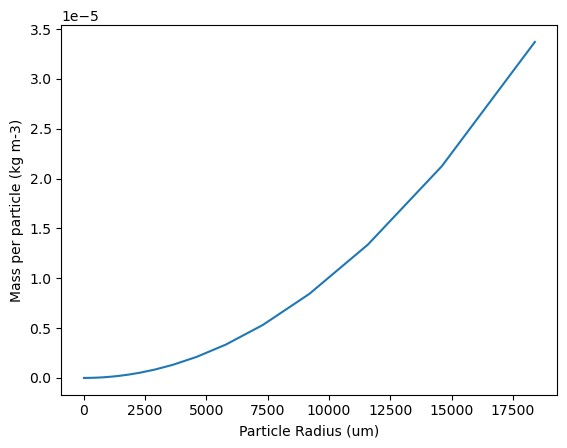

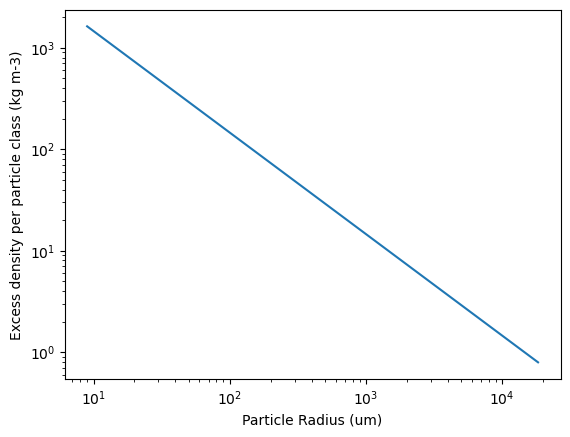

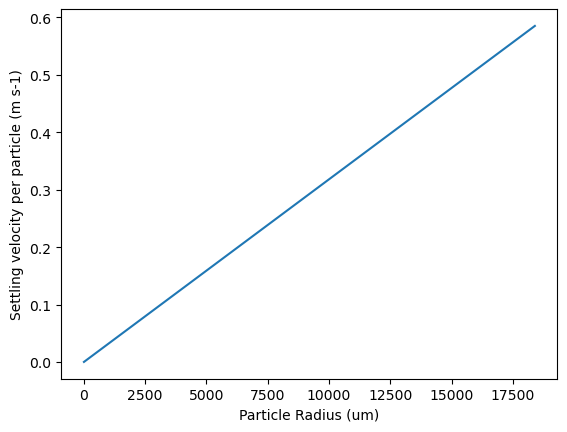

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


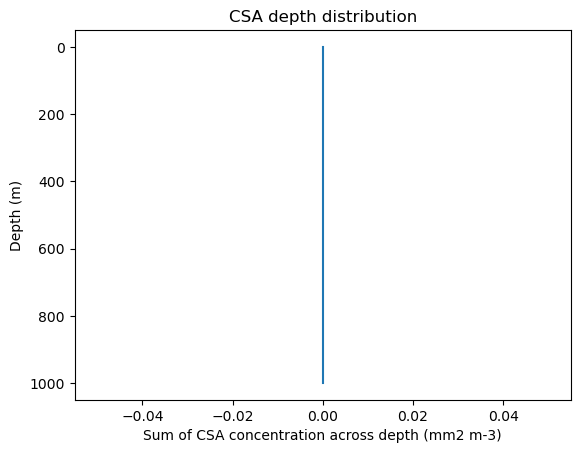

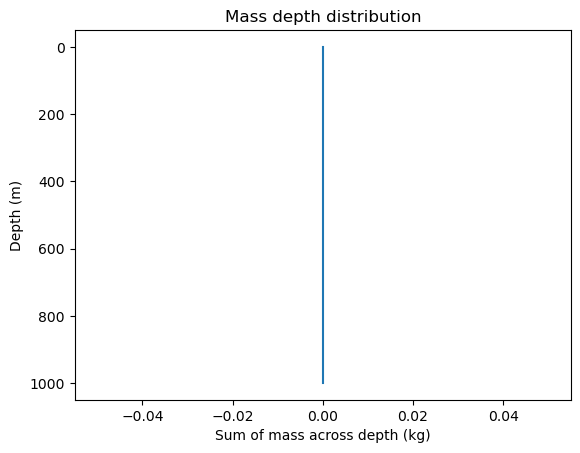

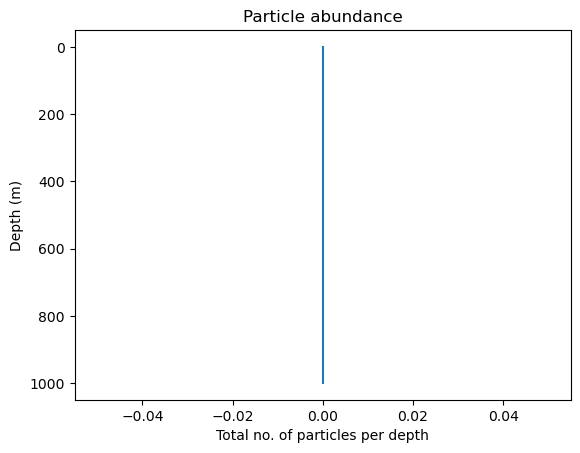

C:\Users\Steffi Hodnett\AppData\Local\Temp\ipykernel_4228\631757875.py:507: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


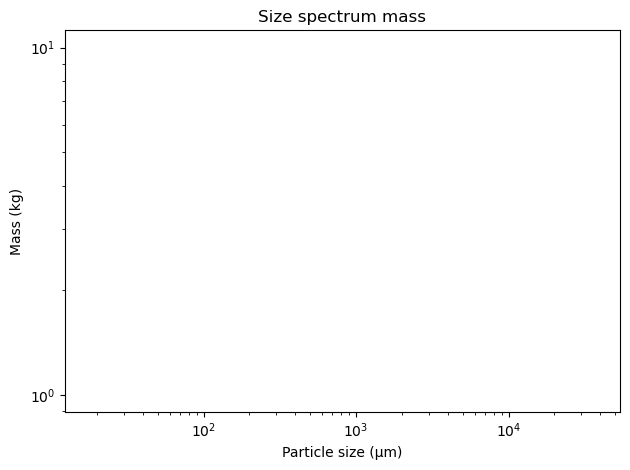

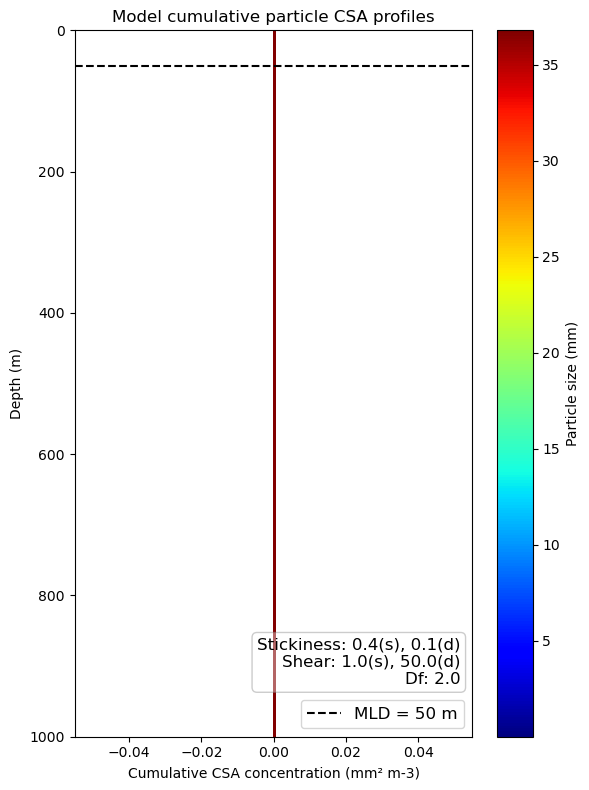

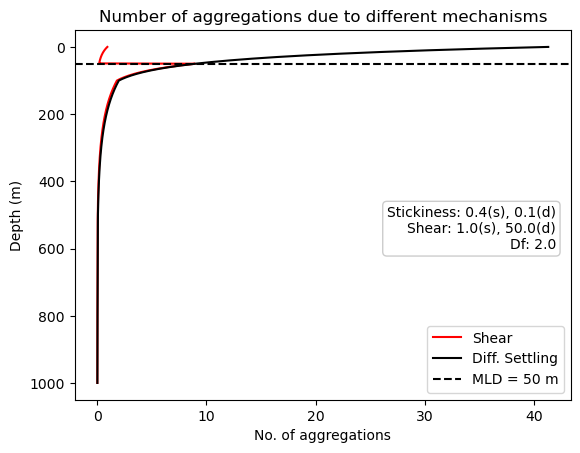

In [ ]:
# MASS MODEL

# ------------------------------
# SIZE BINS
# ------------------------------

size_bounds = 2 ** np.arange(4, 15 + 1/3, 1/3)
# size_bounds = 2 ** np.arange(4, 11, 1)                            # specifies size bins in microns
size_bins = np.sqrt(size_bounds[:-1] * size_bounds[1:])             # calculates mid-size diameter of each bin as geometric mean (due to log spacing)

radius = size_bins / 2.0                                            # calculates radius from diameter (um)
radius_m = radius * 1e-6                                            # converts radius into metres
radius_mm = radius / 1000                                           # converts radius into mm

area_per_particle = np.pi * radius_mm**2                            # (mm2) calculates cross-sectional area (assuming each particle is a circle) for each size bin

n_bins = len(size_bins)                                             # specifying the number of size bins


# ------------------------------
# PARAMETERS
# ------------------------------
Df = 2.0                                                            # Fractal Dimension
rho_f = 1025                                                        # Seawater Density (kg m-3)
rho0 = 2650                                                         # Primary Particle Density (kg m-3)
mu = 1e-3                                                           # Viscosity of seawater
g = 9.81                                                            # Acceleration due to gravity
surface_a = 0.4                                                     # Stickiness (probability of successful collisions) at the surface
deep_a = 0.1                                                       # Stickiness (probability of successful collisions) at depth
surface_G = 1.0                                                    # Turbulent Shear at the surface
deep_G = 50.0                                                        # Turbulent Shear at depth
MLD = 50                                                            # Mixed Layer Depth


# ------------------------------
# INITIAL CSA DISTRIBUTION
# ------------------------------

# Use a CSA spectrum more consistent with UVP data (uses a shallower slope)

CSA0 = 60 #(mm2 m-3)                                                # total starting particle cross-sectional area concentration

CSA_slope = 1.0    # can change back to 3 or 3.5                    # specifies how aggressively the starting distribution varies between small and large particles

CSA = (size_bins / size_bins[0])**(-CSA_slope)                      # how much bigger is each size class than the smallest, then take the reciprocal to flip the probability so that biggest = rarest 
CSA = CSA / np.sum(CSA) * CSA0                                      # divide these individual weightings by their sum which is multiplied by the starting max CSA, so scaling their probabilities up

# number concentration 
N = CSA / area_per_particle  #(mm2 m-3 / mm2 = particles m-3)       # inferring the number of particles in each size class from the total cross-sectional area for each size class

# Mass
r0 = radius_m[0]    #m

V0 = (4/3) * np.pi * r0**3      #[] x [] x m3 = m3
m0 = rho0 * V0  #kg m-3 x m3 = kg

particle_mass = m0 * (radius_m / r0)**Df      #kg * (m/m)^2 which is [] = kg per particle
M = N * particle_mass    # particles m-3 * kg = kg m-3 actually density of particle weight per litre

# -------------------------------------------------------------------
# FUNCTIONS: PARTICLE DENSITY, SETTLING VELOCITY, SHEAR + AGGREGATION
# -------------------------------------------------------------------

def particle_density(r):
    """
    Calculates the density of a particle of given radius (r), based on its size
    relative to primary particle (smallest size class) radius. Radius must be in m.
    """
    
    r0 = radius_m[0]                                         # reference particle = radius of smallest particle in range    
    #rho0 = 2650                                              # smallest primary particle assigned a reference density of 1050 kg m-3, slightly denser than seawater                                        # size of each particle relative to the primary one
    # rho_eff = (rho0 * ((r / r0)**(Df - 3))) - rho_f          # primary particle density x scaling factor to the power of Df - 3 (radial density equation)
    delta_rho = (rho0 - rho_f) * (r / r0)**(Df - 3)
    #rho_eff = rho_f + (rho0 - rho_f) * relative_size**(Df - 3)

    return delta_rho                                           # spits out excess density of particle
                                                                                                            
                                                                                                                                 
excess_densities = []                                                      # This checks the density of the different size classes of particles - need to fix the drop below seawater density
for r in radius_m:                                                  # possibly need to include rule accounting for water density inside aggregate SCH 3/7/26
    density = particle_density(r)
    excess_densities.append(density)

fig, ax = plt.subplots()
ax.plot(radius, particle_mass)
# ax.set_xscale("log")
ax.set_xlabel("Particle Radius (um)")
ax.set_ylabel("Mass per particle (kg m-3)")
plt.tight_layout
plt.show()

fig, ax = plt.subplots()
ax.plot(radius, excess_densities)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Particle Radius (um)")
ax.set_ylabel("Excess density per particle class (kg m-3)")
plt.tight_layout
plt.show()


# ------------------------------
# SETTLING
# ------------------------------

def settling_velocity(r):
    """
    Calculates settling velocity using the Stokes equation.
    # Will need to add correction factor for non-spherical particles?
    """

    rho_eff = particle_density(r)                                   

    return (2/9) * (rho_eff) * g * r**2 / mu                # The Stokes formula, incorporating excess density

sink_velocities = []                                                      
for r in radius_m:                                                    
    speed = settling_velocity(r)
    sink_velocities.append(speed)

fig, ax = plt.subplots()                                            # Graphing the distribution of settling velocity for each particle radius
ax.plot(radius, sink_velocities)                                    # Currently 
ax.set_xlabel("Particle Radius (um)")
ax.set_ylabel("Settling velocity per particle (m s-1)")
plt.tight_layout
plt.show() 


# ------------------------------
# SHEAR
# ------------------------------

def shear_rate(depth):

    if depth < MLD:                                                 # Pretty self-explanatory, MLD marks turbulent shear difference
        return surface_G
    else:
        return deep_G
    
def stickiness(depth):
    
    if depth < MLD:
        return surface_a
    else:
        return deep_a
    
# ------------------------------
# COLLISION KERNELS
# ------------------------------

def shear_kernel(r1, r2, depth):                                    # Need to update for it to be curvilinear rather than rectilinear, for better realism
    """
    Turbulent shear collision kernel.
    """
    G = shear_rate(depth)
    return 1.3 * G * (r1 + r2)**3           # should this be 6 instead of 1.3?


def settling_kernel(r1, r2):
    """
    Differential settling collision kernel.
    """
    w1 = settling_velocity(r1)
    w2 = settling_velocity(r2)

    return np.pi * (r1 + r2)**2 * abs(w1 - w2) # should this be x 4?


def jackson_kernel(
    r1,
    r2,
    depth,
    use_shear=True,
    use_settling=True
):
    """
    Combined Jackson kernel with switchable processes.
    """

    beta = 0.0

    if use_shear:
        beta += shear_kernel(r1, r2, depth)

    if use_settling:
        beta += settling_kernel(r1, r2)

    return beta

# ------------------------------
# DEPTH GRID
# ------------------------------

dz = 1                                                              # Depth step
z_max = 1000                                                        # Max depth
nz = int(z_max / dz)                                                # Number of depth points

# ------------------------------
# STORAGE
# ------------------------------

# N_profile = np.zeros((nz, n_bins))
M_profile = np.zeros((nz, n_bins))                                  # Profile of mass, appended at each depth step
M_profile[0, :] = M     # initialise surface spectrum  ####NEW
CSA_profile = np.zeros((nz, n_bins))                                # Profile of CSA, appended at each depth step

particle_counts = []                                                # Empty arrays for number of particles, their mass, mean and depth
particle_masses = []
mean_sizes = []
depths = []

def number_concentration(M):
    N = np.zeros_like(M)
    mask = particle_mass > 0
    N[mask] = M[mask] / particle_mass[mask]
    return N

# --------------------------------------
# SENSITIVITY ANALYSIS - KERNEL SWITCHES
# --------------------------------------

shear = True                                                    # Set to False or True depending on the variation
settling = True

shear_collision_profile = np.zeros(nz)                          # Setting up profiles that store aggregation rates due to shear and settling
settling_collision_profile = np.zeros(nz)

# ------------------------------
# MAIN MODEL LOOP
# ------------------------------

for z_step in range(nz):                                        # for each depth point, convert to absolute depth (and calculate aggregation rates)

    depth = z_step * dz
    M = M_profile[z_step, :].copy()
        
    M_new = np.zeros_like(M)                                    # records any changes to mass as a result of aggregation

    N = number_concentration(M)

    # diagnostic number concentration
    #N = np.zeros_like(M)                                        # collisions require particle numbers, so calculating here

    #mask = particle_mass > 0                                    # Checking where particle mass is over 0, so that dividing by 0 is avoided when calculating no. of particles 
    #N[mask] = M[mask] / particle_mass[mask]                     # Calculating no. of particles from mass for a bin / mass per particle


    for i in range(n_bins):                                     # For each particle bin

        for j in range(i, n_bins):                              # For each other particle bin, and particles within their own size bins

            if N[i] <= 0 or N[j] <= 0:                          # If no particles in either bin at this depth, move on
                continue

            r1 = radius_m[i]
            r2 = radius_m[j]


            # Running Aggregation Kernels
            #beta = jackson_kernel(r1, r2, depth)
            beta = jackson_kernel(r1, r2, depth, use_shear=shear, use_settling=settling) # Combined kernel

            beta_shear = shear_kernel(r1, r2, depth)            # Turbulent shear aggregation
            beta_settle = settling_kernel(r1, r2)               # Differential settling aggregation

            beta = 0.0                                          # Collision kernel per pair  ###### elaborate

            if shear:                                           # Flipping the switches earlier controls which processes are represented
                beta += beta_shear

            if settling:
                beta += beta_settle

            # dt_local = dz / w
            w = settling_velocity((r1 + r2) / 2)
            dt_local = 3600                                     # 1 hour available for collisions (what happens if this is changed? base it on Argo float ascension speed?)

            # Tracking relative contribution of shear vs differential settling as an aggregation driver
            shear_collision_profile[z_step] += (beta_shear * N[i] * N[j] * dt_local)
            settling_collision_profile[z_step] += (beta_settle * N[i] * N[j] * dt_local)               

            if w <= 0:                                          # if the resulting aggregate would be buoyant, skip it
                continue

            collisions = beta * N[i] * N[j] * dt_local          # Computes no. of collisions - if beta, particle number and time at depth are larger = more collisions

            if i == j:
                collisions *= 0.5                               # Applies half-counting

            # aim to expand this to include a different stickiness for >MLD and <MLD
            agg = stickiness(depth) * collisions


            if i == j:                                          # don't allow more collisions than particles present
                agg = min(agg, N[i] / 2)
            else:
                agg = min(agg, N[i], N[j])

            # exact mass removed
            mass_i = agg * particle_mass[i]                     # calculate mass removed, e.g. no. of aggregations * particle mass
            mass_j = agg * particle_mass[j]                     # for the other size class in each pair

            total_mass = mass_i + mass_j                        # total mass of aggregate (assumes steady state)

            # remove mass                                       # removes mass from parent bins
            M_new[i] -= mass_i
            M_new[j] -= mass_j
                        
            # Resolves into length properly
            new_particle_mass = particle_mass[i] + particle_mass[j]
            # radius of new aggregate (m)
            new_radius = r0 * (new_particle_mass / m0)**(1 / Df)
            # convert to diameter in microns to match size_bins
            new_size = 2 * new_radius * 1e6

            # destination bin                                   # This can be edited to distribute mass more evenly....
            k = np.argmin(
            np.abs(size_bins - new_size)
            )

            
        # add exactly the same mass
            M_new[k] += total_mass                              # ...and this too


    M += M_new
    

    def remin_rate(depth):

        if depth < 100:
            return 0.01

        elif depth < 500:
            return 0.003

        else:
            return 0.001
    

    lambda_rem = remin_rate(depth)

    M -= lambda_rem * M * dz


    lambda_size = (lambda_rem * (size_bins / size_bins[0])**(-0.5))

    loss = lambda_size * M * dz

    M -= loss

    # ------------------------------
    # DIFFUSION
    # ------------------------------

    diffusion = 0.02

    M_diff = np.zeros_like(M)

    for i in range(n_bins):

        spread = diffusion * M[i]

        if i > 0:
            M_diff[i] -= spread
            M_diff[i-1] += spread

        if i < n_bins-1:
            M_diff[i] -= spread
            M_diff[i+1] += spread

    M += M_diff
    """
    print(
    depth,
    np.sum(M),
    np.max([settling_velocity(r) for r in radius_m])
    )
    """
    # ------------------------------
    # SINKING FLUX
    # ------------------------------

    M_sink = np.zeros_like(M)

    for i in range(n_bins):

        w = settling_velocity(radius_m[i])

        flux_out = M[i] * w                # kg m-2 s-1

        #transfer = flux_out * dt_local / dz   # kg m-3

        fraction = min(
            settling_velocity(radius_m[i]) * dt_local / dz,
            1.0
        )

        transfer = M[i] * fraction

        transfer = min(transfer, M[i])     # prevent negative mass

        M_sink[i] -= transfer              # remove from current layer

        if z_step < nz - 1:
            M_profile[z_step + 1, i] += transfer

    M += M_sink
    M_profile[z_step, :] = M

    fractions = []

    for i in range(n_bins):
        fractions.append(
            min(settling_velocity(radius_m[i]) * dt_local / dz, 1.0)
        )

    print(np.min(fractions))
    print(np.max(fractions))
    """
    print(
    z_step,
    np.sum(M),
    np.sum(M_profile[z_step+1,:]) if z_step < nz-1 else 0
    )
    """
    #mask = particle_mass > 0

    #N[mask] = M[mask] / particle_mass[mask]

    # prevent negatives
    # M[M < 0] = 0
    
    # ------------------------------
    # DERIVED CSA
    # ------------------------------
    # save profiles
    # N_profile[z_step, :] = N
    N = number_concentration(M)
    CSA = N * area_per_particle
    M_profile[z_step, :] = M
    CSA_profile[z_step, :] = CSA
  
    # diagnostics
    total_number = np.sum(N) 
    total_mass = np.sum(M) 

    mean_size = (
        np.sum(N * size_bins) / total_number
        if total_number > 0 else 0
    )

    particle_counts.append(total_number)
    particle_masses.append(total_mass)
    mean_sizes.append(mean_size)
    depths.append(depth)

parameters = f"Stickiness: {surface_a}(s), {deep_a}(d)\nShear: {surface_G}(s), {deep_G}(d)\nDf: {Df}"

# --------------------------------
# CROSS-SECTIONAL AREA DEPTH CHECK
# --------------------------------
total_CSA = np.sum(CSA_profile, axis=1)

fig, ax = plt.subplots()

ax.plot(total_CSA, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of CSA concentration across depth (mm2 m-3)")   # check units
ax.set_ylabel("Depth (m)")
ax.set_title("CSA depth distribution")

plt.show()

# ------------------------------
# MASS CONSERVATION CHECK
# ------------------------------
fig, ax = plt.subplots()

ax.plot(particle_masses, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of mass across depth (kg)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mass depth distribution")

plt.show()

# ------------------------------
# NUMBER OF PARTICLES CHECK
# ------------------------------

fig, ax = plt.subplots()

ax.plot(particle_counts, depths)
ax.invert_yaxis()
ax.set_xlabel("Total no. of particles per depth")
ax.set_ylabel("Depth (m)")
ax.set_title("Particle abundance")

plt.show()

# ------------------------------
# SIZE BIN BEHAVIOUR CHECK
# ------------------------------

fig, ax = plt.subplots()
ax.plot(size_bins, M, marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Particle size (µm)")
ax.set_ylabel("Mass (kg)")
ax.set_title("Size spectrum mass")

plt.tight_layout()
plt.show()


# ------------------------------
# CSA CUMULATIVE PLOT
# ------------------------------

fig, ax = plt.subplots(figsize=(6,8))

cumulative = np.cumsum(CSA_profile.T, axis=0)

cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, n_bins))

for i in range(n_bins):

    ax.plot(
        cumulative[i, :],
        depths,
        color=colors[i],
        linewidth=2
    )

ax.axhline(
    y=MLD,
    color="black",
    linestyle="--",
    label=f"MLD = {MLD} m"
)

#ax.set_xscale("log")
ax.invert_yaxis()

ax.set_xlabel("Cumulative CSA concentration (mm² m-3)")
ax.set_ylabel("Depth (m)")
norm = plt.Normalize(
    vmin=min(size_bins/1000),
    vmax=max(size_bins/1000)
)
ax.set_title(f"Model cumulative particle CSA profiles")
ax.legend(loc="lower right", fontsize=12)
ax.set_ylim(0, 1000)

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

plt.colorbar(sm, ax=ax, label="Particle size (mm)")
ax.text(0.97, 0.07, 
        f"Stickiness: {surface_a}(s), {deep_a}(d)\nShear: {surface_G}(s), {deep_G}(d)\nDf: {Df}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12,
        bbox=dict(
            boxstyle='round, pad=0.3',
            facecolor="white",
            edgecolor="grey",
            alpha=0.4,
            linewidth=1
        ))

ax.invert_yaxis()
plt.tight_layout()
plt.show()

# -------------------------------------------
# RELATIVE COLLISION KERNEL CONTRIBUTION PLOT
# -------------------------------------------

fig, ax = plt.subplots()
ax.plot(shear_collision_profile, depths, color="r", label="Shear")
ax.plot(settling_collision_profile, depths, color="black", label="Diff. Settling")
ax.set_title("Number of aggregations due to different mechanisms")
ax.set_xlabel("No. of aggregations")
ax.set_ylabel("Depth (m)")
ax.axhline(y=MLD, color="black", linestyle="--",label=f"MLD = {MLD} m")
ax.text(0.97, 0.4, 
        f"Stickiness: {surface_a}(s), {deep_a}(d)\nShear: {surface_G}(s), {deep_G}(d)\nDf: {Df}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10,
        bbox=dict(
            boxstyle='round, pad=0.3',
            facecolor="white",
            edgecolor="grey",
            alpha=0.4,
            linewidth=1
        ))
ax.legend()
ax.invert_yaxis()
plt.show()




17
[1.00000000e+00 1.58740105e+00 2.51984210e+00 4.00000000e+00
 6.34960421e+00 1.00793684e+01 1.60000000e+01 2.53984168e+01
 4.03174736e+01 6.40000000e+01 1.01593667e+02 1.61269894e+02
 2.56000000e+02 4.06374669e+02 6.45079578e+02 1.02400000e+03
 1.62549868e+03 2.58031831e+03]


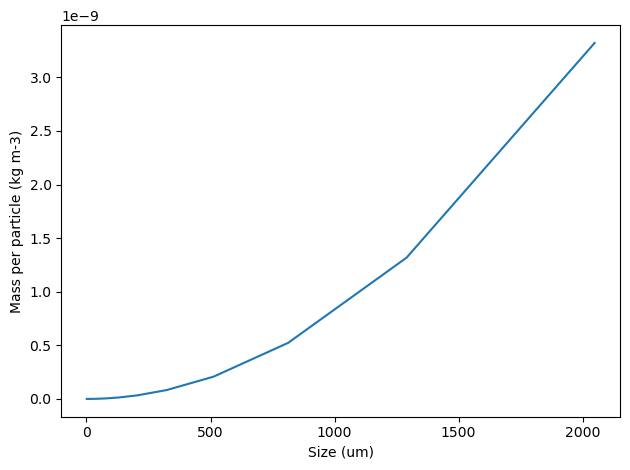

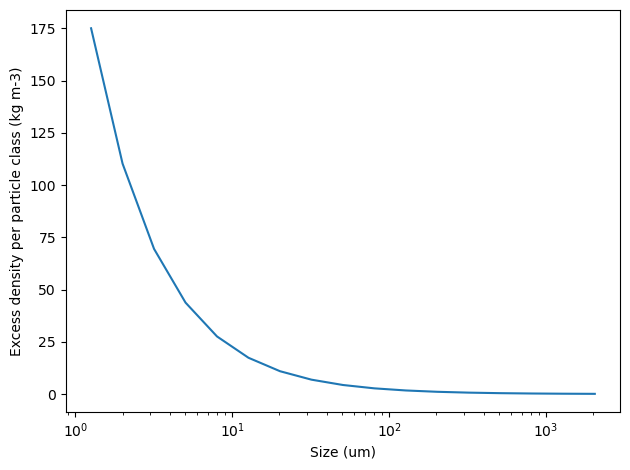

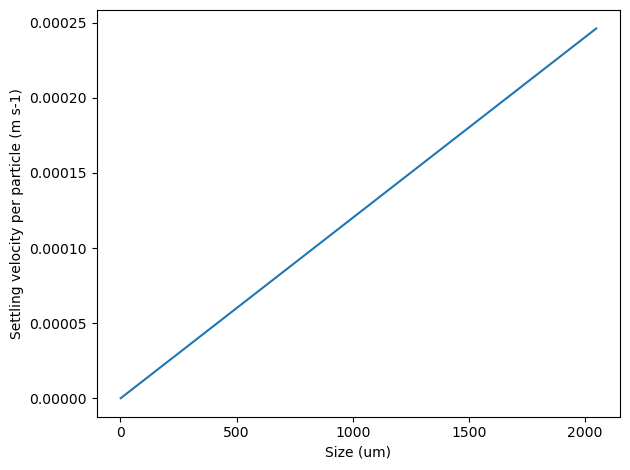

[6.60509069e+06 5.10557935e+06 3.75306079e+06 ... 6.45028388e+03
 4.98591734e+03 4.06342422e+03]


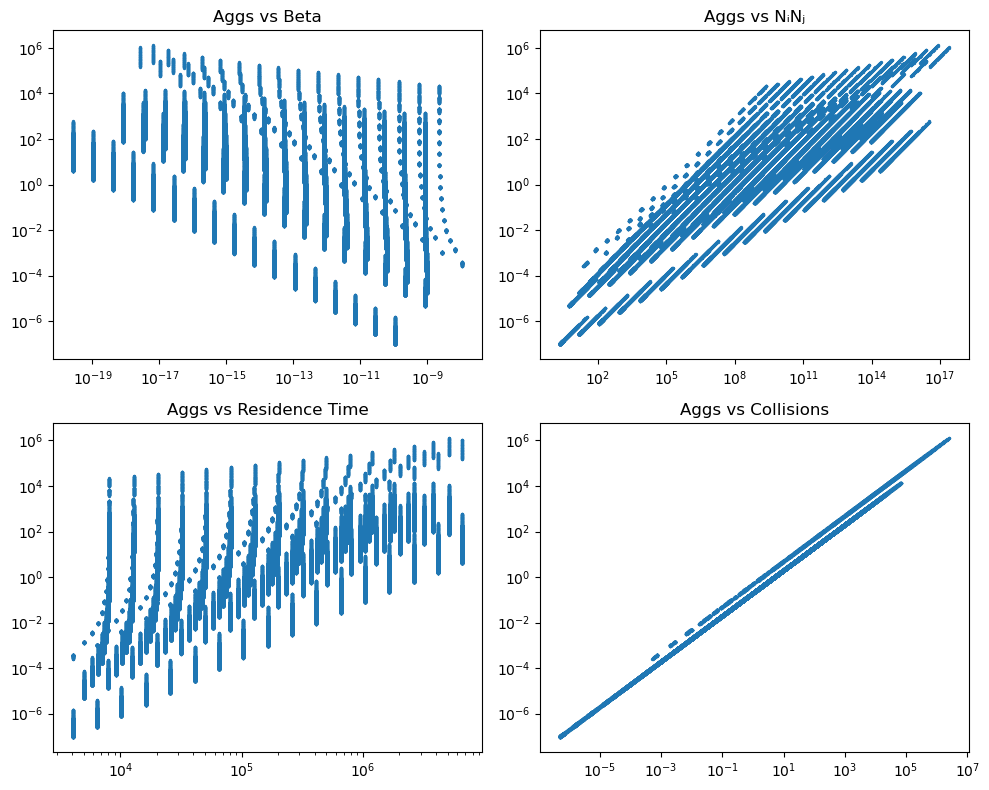

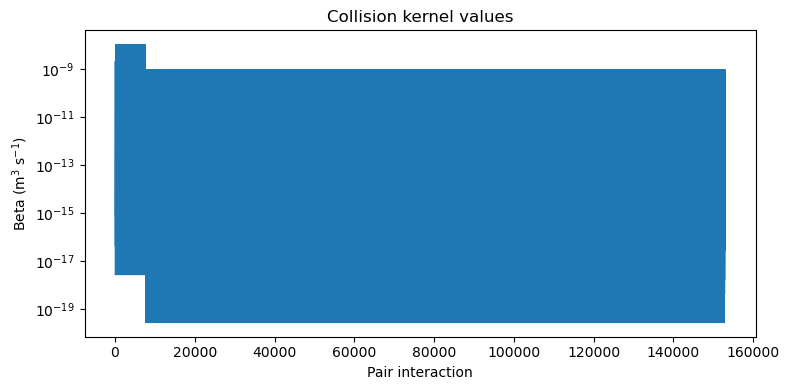

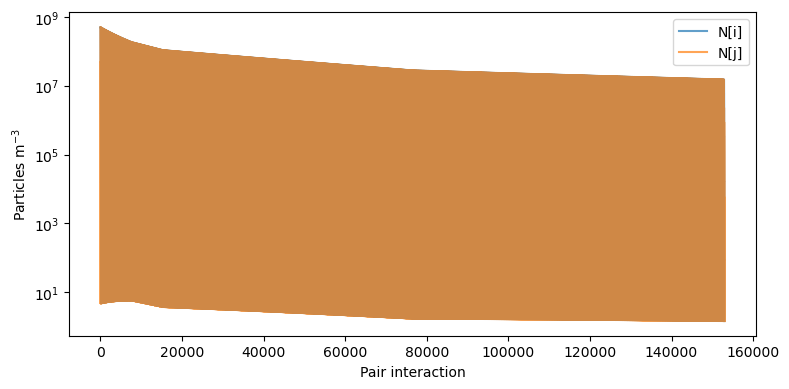

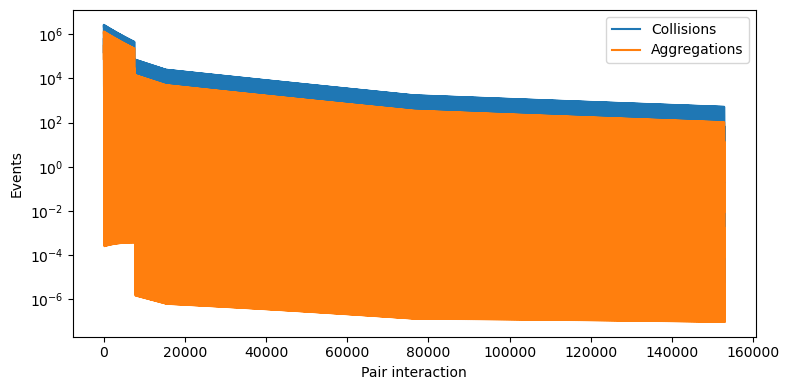

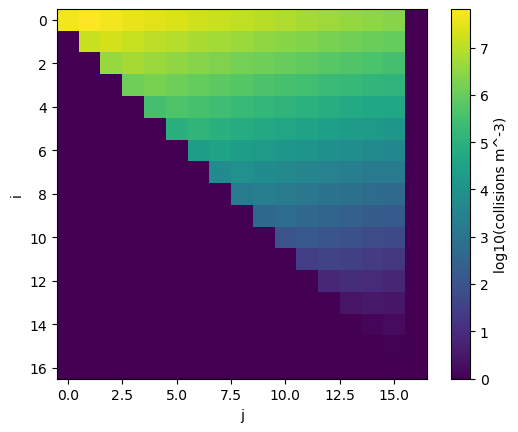

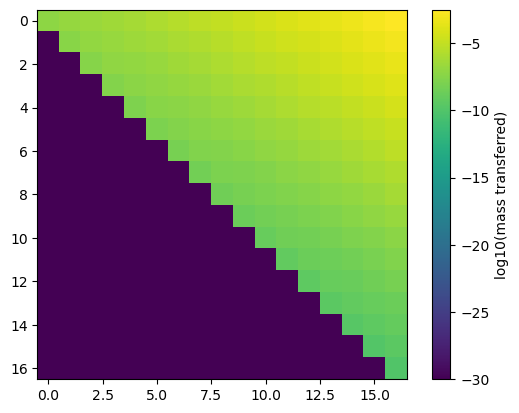

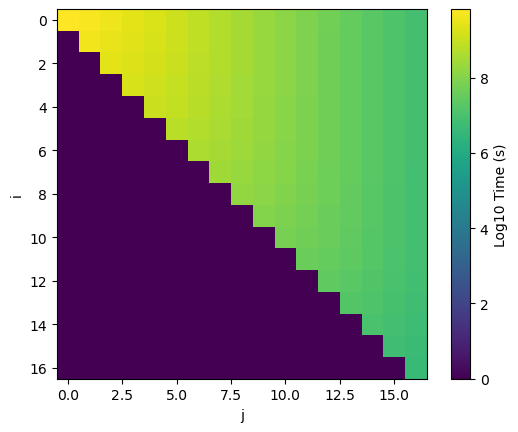

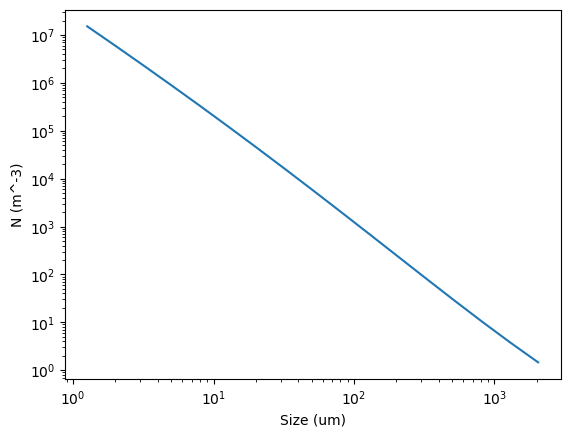

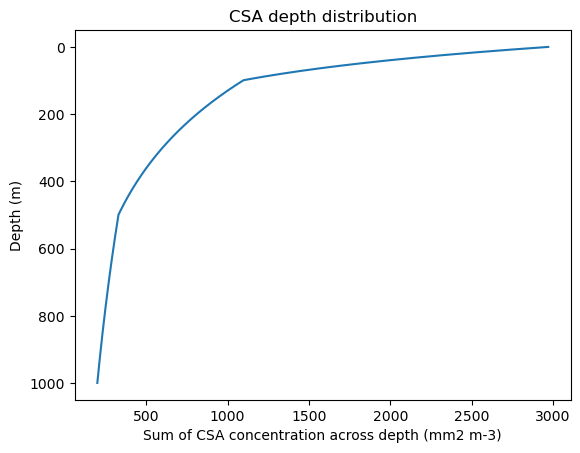

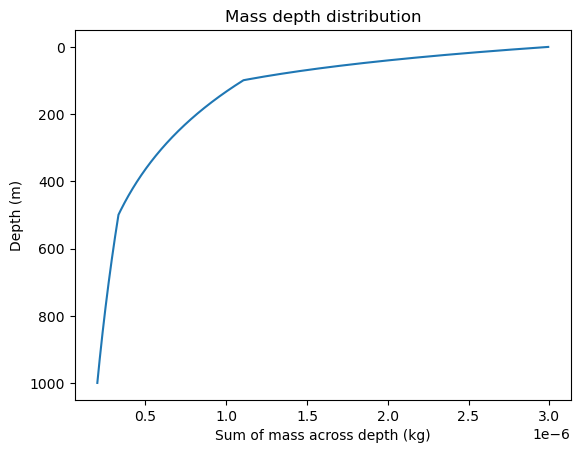

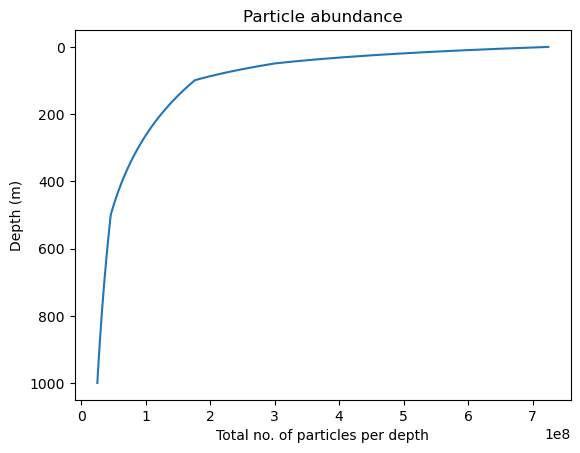

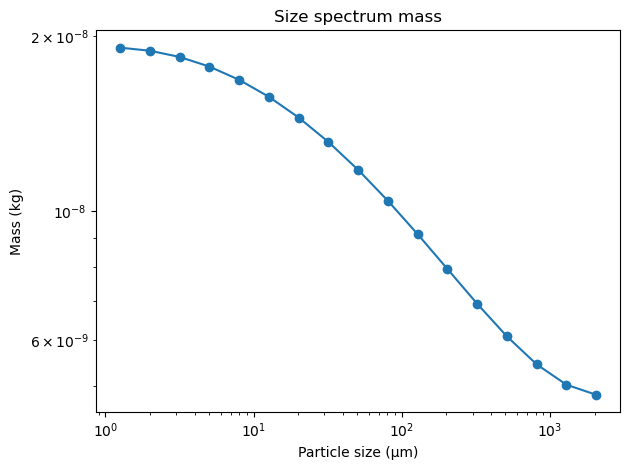

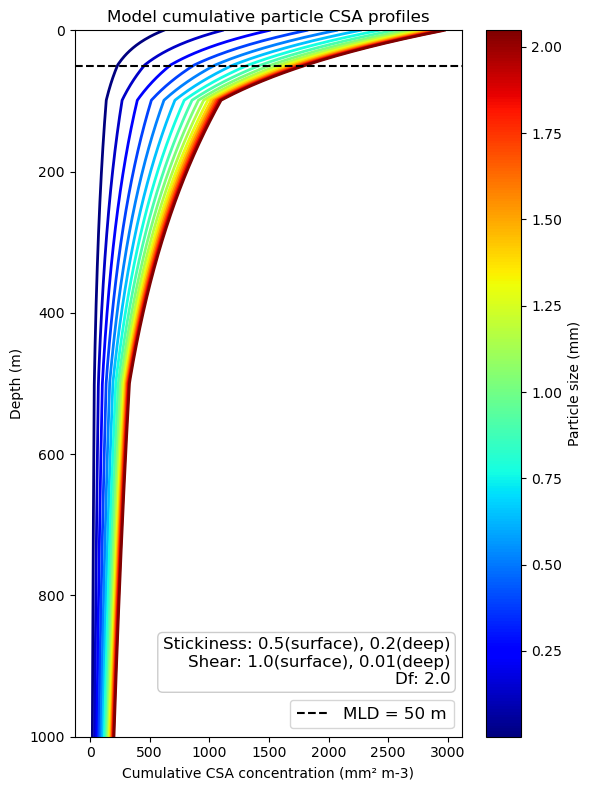

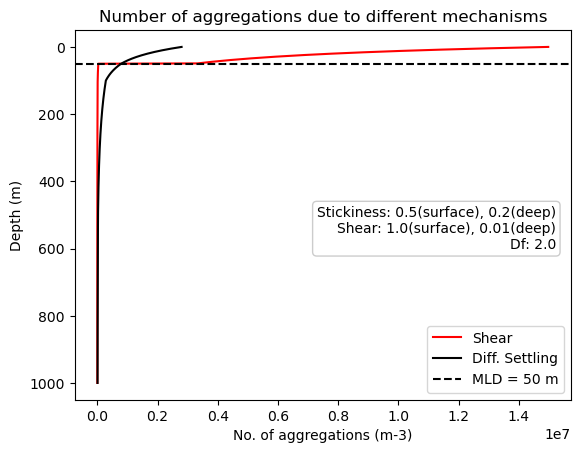

In [ ]:
# FLUX MODEL (plz work)

# ------------------------------
# SIZE BINS
# ------------------------------

size_bounds = 2 ** np.arange(0, 11 + 1/3, 2/3) #um     # OG 4       # 16 um to 2050 um (22 bins)
size_bins = np.sqrt(size_bounds[:-1] * size_bounds[1:]) # um        # calculates mid-size diameter of each bin as geometric mean (due to log spacing)
n_bins = len(size_bins)                                             # specifying the number of size bins
print(n_bins)
print(size_bounds)


radius = size_bins / 2.0 #um                                       # calculates radius from diameter (um)
radius_m = radius / 1e6  #m                                        # converts radius into metres
radius_mm = radius / 1000  #mm                                     # converts radius into mm

area_per_particle = np.pi * radius_mm**2  # mm2                    # (mm2) calculates cross-sectional area (assuming each particle is a circle) for each size bin


# ------------------------------
# PARAMETERS
# ------------------------------
Df = 2.0                                                            # Fractal Dimension
rho_f = 1025                         # kg m-3                       # Seawater Density (kg m-3)
rho0 = 1200 #(Li et al, 2004)        # kg m-3                       # Primary Particle Density (kg m-3)
mu = 1e-3                            # Pa s                           # Viscosity of seawater
g = 9.81                             # m s-2                        # Acceleration due to gravity
surface_a = 0.5                                                     # Stickiness (probability of successful collisions) at the surface
deep_a = 0.2                                                       # Stickiness (probability of successful collisions) at depth
surface_G = 1.0                      # s-1   (Maerz et al 2020)     # Turbulent Shear at the surface
deep_G = 0.01                        # s-1   (Maerz et al 2020)     # Turbulent Shear at depth
MLD = 50                             # m                            # Mixed Layer Depth


# ------------------------------
# INITIAL CSA DISTRIBUTION
# ------------------------------

# Use a CSA spectrum more consistent with UVP data (uses a shallower slope)

CSA0 = 3000 #(mm2 m-3)                                                # total surface starting particle cross-sectional area concentration

CSA_slope = 0.5   # higher = steep, more small particles, lower = gentler, more large particles           # specifies how aggressively the starting distribution varies between small and large particles

CSA = (size_bins / size_bins[0])**(-CSA_slope)                      # how much bigger is each size class than the smallest, then take the reciprocal to flip the probability so that biggest = rarest 
CSA = CSA / np.sum(CSA) * CSA0                                      # divide these individual weightings by their sum which is multiplied by the starting max CSA, so scaling their probabilities up

# number concentration 
N = CSA / area_per_particle  #(mm2 m-3 / mm2 = particles m-3)       # inferring the number of particles in each size class from the total cross-sectional area for each size class


# Mass
r0 = radius_m[0]    #reference particle (m)
V0 = (4/3) * np.pi * r0**3      #[] x [] x m3 = m3
m0 = rho0 * V0  #kg m-3 x m3 = kg
particle_mass = m0 * (radius_m / r0)**Df      #kg * (m/m)^2 which is [] = kg per particle (mass propor. to r^x)
M = N * particle_mass    # particles m-3 * kg = kg associated with particles per m-3 per size class

# -------------------------------------------------------------------
# FUNCTIONS: PARTICLE DENSITY, SETTLING VELOCITY, SHEAR + AGGREGATION
# -------------------------------------------------------------------

def particle_density(r):
    """
    Calculates the density of a particle of given radius (r), based on its size
    relative to primary particle (smallest size class) radius. Radius must be in m.
    """
    
    r0 = radius_m[0]  # m                                      # reference particle = radius of smallest particle in range                                                                                         
    rho = (rho0 - rho_f) * (r / r0)**(Df - 3) # kg m-3 * (m/m)^2 = kg m-3 
    return rho
    """
    if delta_rho > rho_f:
        return (delta_rho)                                         # spits out excess density of particle
    else:
        return (rho_f)                                             # spits out excess density of particle
    """                                                                                                     
                                                                                                                                 
excess_densities = []                                                      
for r in radius_m:                                                  
    density = particle_density(r)
    excess_densities.append(density)#

fig, ax = plt.subplots()
ax.plot(size_bins, particle_mass)
#ax.set_xscale("log")
ax.set_xlabel("Size (um)")
ax.set_ylabel("Mass per particle (kg m-3)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(size_bins, excess_densities)
ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("Size (um)")
ax.set_ylabel("Excess density per particle class (kg m-3)")
plt.tight_layout()
plt.show()


# ------------------------------
# SETTLING
# ------------------------------

def settling_velocity(r):
    """
    Calculates settling velocity using the Stokes equation.
    # Will need to add correction factor for non-spherical particles?
    """
    rho_eff = particle_density(r) # kg m-3                                   

    return (2/9) * (rho_eff) * g * r**2 / mu # kg m-3 * m s-2 * m^2 / (Pa s) = m s-1               # The Stokes formula, incorporating excess density

sink_velocities = []                                                      
for r in radius_m:                                                    
    speed = settling_velocity(r)
    sink_velocities.append(speed)

fig, ax = plt.subplots()                                            # Graphing the distribution of settling velocity for each particle radius
ax.plot(size_bins, sink_velocities)                                    # Currently 
ax.set_xlabel("Size (um)")
ax.set_ylabel("Settling velocity per particle (m s-1)")
plt.tight_layout()
plt.show() 


# ------------------------------
# SHEAR
# ------------------------------

def shear_rate(depth):

    if depth < MLD:                                                 # Pretty self-explanatory, MLD marks turbulent shear difference
        return surface_G
    else:
        return deep_G
    
def stickiness(depth):
    
    if depth < MLD:
        return surface_a
    else:
        return deep_a
    
# ------------------------------
# COLLISION KERNELS
# ------------------------------

def shear_kernel(r1, r2, depth, use_shear=True):                                    # Need to update for it to be curvilinear rather than rectilinear, for better realism
    """
    Turbulent shear collision kernel.
    """
    if use_shear:
        G = shear_rate(depth)
        return 1.3 * G * (r1 + r2)**3  # s-1 * m^3 = m^3 s-1              
    else:
        return 0.0


def settling_kernel(r1, r2, use_settling=True):
    """
    Differential settling collision kernel.
    """
    if use_settling:
        w1 = settling_velocity(r1)
        w2 = settling_velocity(r2)
        return np.pi * (r1 + r2)**2 * abs(w1 - w2) # m^2 * m s-1 = m^3 s-1 
    else:
        return 0.0


def jackson_kernel(
    r1,
    r2,
    depth,
    use_shear=True,
    use_settling=True
):
    """
    Combined Jackson kernel with switchable processes.
    """

    beta = 0.0

    if use_shear == True:
        beta += shear_kernel(r1, r2, depth, use_shear=use_shear)
    if use_shear == False:
        beta += 0.0

    if use_settling == True:
        beta += settling_kernel(r1, r2, use_settling=use_settling)
    if use_settling == False:
        beta += 0.0

    return beta

# ------------------------------
# DEPTH GRID
# ------------------------------

dz = 1 # m                                                          # Depth step
z_max = 1000 # m                                                    # Max depth
nz = int(z_max / dz)                                                # Number of depth points

# ------------------------------
# STORAGE
# ------------------------------

# N_profile = np.zeros((nz, n_bins))
M_profile = np.zeros((nz, n_bins))                                  # Profile of mass, appended at each depth step
Flux_profile = np.zeros((nz, n_bins))
for i in range(n_bins):
    Flux_profile[0, i] = (M[i] * settling_velocity(radius_m[i]))
CSA_profile = np.zeros((nz, n_bins))                                # Profile of CSA, appended at each depth step

particle_counts = []                                                # Empty arrays for number of particles, their mass, mean and depth
particle_masses = []
mean_sizes = []
depths = []

def number_concentration(M):
    N = np.zeros_like(M)                                             
                                                                    
    mask = particle_mass > 0                                        # Checking where particle mass is over 0, so that dividing by 0 is avoided when calculating no. of particles
    N[mask] = M[mask] / particle_mass[mask]                         # Calculating no. of particles from mass for a bin / mass per particle
    return N

# --------------------------------------
# SENSITIVITY ANALYSIS - KERNEL SWITCHES
# --------------------------------------

shear = True                                                   # Set to False or True depending on the variation
settling = True

shear_collision_profile = np.zeros(nz)                          # Setting up profiles that store aggregation rates due to shear and settling
settling_collision_profile = np.zeros(nz)


collision_matrix = np.zeros((n_bins, n_bins))
mass_transfer_matrix = np.zeros((n_bins, n_bins))
time_matrix = np.zeros((n_bins, n_bins))

# ------------------------------
# MAIN MODEL LOOP
# ------------------------------

for z_step in range(nz):                                        # for each depth point, convert to absolute depth (and calculate aggregation rates)

    depth = z_step * dz # m                                             # Absolute depth
    F = Flux_profile[z_step, :].copy()   # kg m-2 s-1

    M = np.zeros_like(F)

    for i in range(n_bins):
        w = settling_velocity(radius_m[i]) # m s-1               # converts flux into mass
        if w > 0:
            M[i] = F[i] / w # kg m-2 s-1 / m s-1 = kg m-3
        
    M_new = np.zeros_like(M)                                    # records any changes to mass as a result of aggregation

    N = number_concentration(M) # particles m-3

    for i in range(n_bins):                                     # For each particle bin

        for j in range(i, n_bins):                              # For each other particle bin, and particles within their own size bins

            if N[i] <= 0 or N[j] <= 0:                          # If no particles in either bin at this depth, move on
                continue

            r1 = radius_m[i]
            r2 = radius_m[j]

            # Running Aggregation Kernels
            beta = jackson_kernel(r1, r2, depth, use_shear=shear, use_settling=settling) # Combined kernel

            beta_shear = shear_kernel(r1, r2, depth, use_shear=shear)            # Turbulent shear aggregation
            beta_settle = settling_kernel(r1, r2, use_settling=settling)               # Differential settling aggregation

            beta = 0.0 # m-3 s-1                                        

            if shear:                                           # Flipping the switches earlier controls which processes are represented
                beta += beta_shear

            if settling:
                beta += beta_settle

            ##### Diagnosing: if setting the settling velocity to that of the primary particles instead of aggregate increases aggregation rates
            w_mean = max((np.mean([settling_velocity(r1), settling_velocity(r2)])), 1e-12)  # m s-1
            dt_local = dz / w_mean   # m / (m s-1) = s, time available for collisions at this depth step
            #dt_local = 3600
            time_matrix[i, j] += dt_local
            '''
            shear_contrib = beta_shear * N[i] * N[j] * dt_local
            settling_contrib = beta_settle * N[i] * N[j] * dt_local

            if i == j:
                shear_contrib *= 0.5
                settling_contrib *= 0.5

            shear_contrib *= stickiness(depth)
            settling_contrib *= stickiness(depth)

            shear_collision_profile[z_step] += shear_contrib
            settling_collision_profile[z_step] += settling_contrib

            '''
            # Tracking relative contribution of shear vs differential settling as an aggregation driver
            shear_collision_profile[z_step] += (beta_shear * N[i] * N[j] * dt_local) # m-3 s-1 * m-3 * m-3 * s = m-3
            settling_collision_profile[z_step] += (beta_settle * N[i] * N[j] * dt_local) # m-3 s-1 * m-3 * m-3 * s = m-3

            '''
            # Apply half counting and stickiness to shear and settling profiles
            if i == j:
                shear_collision_profile[z_step] *= 0.5
                settling_collision_profile[z_step] *= 0.5
            
            shear_collision_profile[z_step] *= stickiness(depth)
            settling_collision_profile[z_step] *= stickiness(depth)
            
            '''

            #if w <= 0:                                          # if the resulting aggregate would be buoyant, skip it
                #continue

            collisions = beta * N[i] * N[j] * dt_local          # Computes no. of collisions - if beta, particle number and time at depth are larger = more collisions
            # [] * [] * s = [] = no. of collisions m-3

            if i == j:
                collisions *= 0.5                               # Applies half-counting

            # stickiness
            agg = stickiness(depth) * collisions


           
            if i == j:                                          # don't allow more collisions than particles present
                agg = min(agg, N[i] / 2)
            else:
                agg = min(agg, N[i], N[j])
            

            ##### Plot to look at the correlation of beta with each of the other variables
            ##### Possibly reduce model to 2 size classes (maybe keep), then make a plot to track 
            ##### beta value, number of particles, collisions, aggs, to track what is causing the bottleneck

            # exact mass removed
            mass_i_deficit = agg * particle_mass[i]                     # calculate mass removed, e.g. no. of aggregations * particle mass
            mass_j_deficit = agg * particle_mass[j]                     # for the other size class in each pair

            total_mass_deficit = mass_i_deficit + mass_j_deficit        # from all the aggregations, what is the mass deficit in origin bins from particles colliding                

            # remove mass                                       # removes mass from parent bins
            M_new[i] -= mass_i_deficit
            M_new[j] -= mass_j_deficit
                        
            # Resolves into length properly
            new_particle_mass = particle_mass[i] + particle_mass[j]
            # radius of new aggregate (m)
            new_radius = r0 * (new_particle_mass / m0)**(1 / Df)
            # convert to diameter in microns to match size_bins
            new_size = 2 * new_radius * 1e6

            mass_transfer_matrix[i,j] += (agg *(particle_mass[i] + particle_mass[j]))
      
            # Find surrounding bins
            k_upper = np.searchsorted(size_bins, new_size)

            # Handle edge cases
            if k_upper <= 0:
                M_new[0] += total_mass_deficit
                continue

            if k_upper >= n_bins:                       # if the new size is bigger than the largest bin, add it to the last bin
                M_new[-1] += total_mass_deficit
                continue

            k_lower = k_upper - 1                       # why is this here? because the upper bin is the first bin that is larger than the new size, so the lower bin is the one just below it

            size_lower = size_bins[k_lower]             # the lower size that is smaller than the new size
            size_upper = size_bins[k_upper]             # the upper size that is larger than the new size

            # Linear interpolation weights              # why is this here? because the new size is between two bins, so we need to distribute the mass between them based on how close it is to each bin
            w_upper = (
                (new_size - size_lower) / (size_upper - size_lower))

            w_lower = 1.0 - w_upper

            # Distribute mass between neighbouring bins
            M_new[k_lower] += total_mass_deficit * w_lower      # assigning mass to the respective bin based on how close the new size is to each bin
            M_new[k_upper] += total_mass_deficit * w_upper
            
            collision_matrix[i,j] += collisions

    M += M_new
    
    
    def remin_rate(depth):    

        if depth < 100:
            return 0.01

        elif depth < 500:
            return 0.003

        else:
            return 0.001
    
    lambda_rem = remin_rate(depth)
    loss = lambda_rem * M * dz
        
    M -= loss
    
    # ------------------------------
    # DIFFUSION
    # ------------------------------

    diffusion = 0.01

    M_diff = np.zeros_like(M)

    for i in range(n_bins):

        spread = diffusion * M[i]

        if i > 0:
            M_diff[i] -= spread
            M_diff[i-1] += spread

        if i < n_bins-1:
            M_diff[i] -= spread
            M_diff[i+1] += spread

    M += M_diff
    
    # ------------------------------
    # SINKING FLUX
    # ------------------------------
 
    F_new = np.zeros_like(M)

    for i in range(n_bins):

        w = settling_velocity(radius_m[i])

        F_new[i] = w * M[i]

    # send downward
    if z_step < nz - 1:

        Flux_profile[z_step + 1, :] += F_new
    
    
    M_profile[z_step, :] = M

    N = number_concentration(M)
    CSA = N * area_per_particle
    CSA_profile[z_step, :] = CSA
    

    # ------------------------------
    # DERIVED TOTAL VALUES
    # ------------------------------
  
    # diagnostics
    total_number = np.sum(N) 
    total_mass = np.sum(M)
  
    particle_counts.append(total_number)
    particle_masses.append(total_mass)
    depths.append(depth)





diag_depth = np.array(diag_depth)

diag_beta = np.array(diag_beta)
diag_beta_shear = np.array(diag_beta_shear)
diag_beta_settle = np.array(diag_beta_settle)

diag_Ni = np.array(diag_Ni)
diag_Nj = np.array(diag_Nj)

diag_dt = np.array(diag_dt)

diag_collisions = np.array(diag_collisions)
diag_aggs = np.array(diag_aggs)

diag_particle_total = np.array(diag_particle_total)

########
# WHAT CONTROLS AGGREGATION
########

print(diag_dt)

fig, axs = plt.subplots(2,2, figsize=(10,8))

axs[0,0].scatter(diag_beta, diag_aggs, s=2)
axs[0,0].set_xscale("log")
axs[0,0].set_yscale("log")
axs[0,0].set_title("Aggs vs Beta")

axs[0,1].scatter(diag_Ni*diag_Nj, diag_aggs, s=2)
axs[0,1].set_xscale("log")
axs[0,1].set_yscale("log")
axs[0,1].set_title("Aggs vs NᵢNⱼ")

axs[1,0].scatter(diag_dt, diag_aggs, s=2)
axs[1,0].set_xscale("log")
axs[1,0].set_yscale("log")
axs[1,0].set_title("Aggs vs Residence Time")

axs[1,1].scatter(diag_collisions, diag_aggs, s=2)
axs[1,1].set_xscale("log")
axs[1,1].set_yscale("log")
axs[1,1].set_title("Aggs vs Collisions")

plt.tight_layout()
plt.show()


## How does beta evolve over the aggregation process?
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(diag_beta, lw=0.5)

ax.set_yscale("log")
ax.set_xlabel("Pair interaction")
ax.set_ylabel("Beta (m$^3$ s$^{-1}$)")
ax.set_title("Collision kernel values")

plt.tight_layout()
plt.show()


# Number concentration
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(diag_Ni, label="N[i]", alpha=0.7)
ax.plot(diag_Nj, label="N[j]", alpha=0.7)

ax.set_yscale("log")
ax.set_xlabel("Pair interaction")
ax.set_ylabel("Particles m$^{-3}$")

ax.legend()

plt.tight_layout()
plt.show()


# Collisions vs Aggregations
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(diag_collisions, label="Collisions")
ax.plot(diag_aggs, label="Aggregations")

ax.set_yscale("log")

ax.set_xlabel("Pair interaction")
ax.set_ylabel("Events")

ax.legend()

plt.tight_layout()
plt.show()







    
plt.imshow(np.log10(collision_matrix + 1))
plt.colorbar(label="log10(collisions m^-3)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

plt.imshow(np.log10(mass_transfer_matrix + 1e-30))
plt.colorbar(label="log10(mass transferred)")
plt.show()

plt.imshow(np.log10(time_matrix + 1))
plt.colorbar(label="Log10 Time (s)")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

fig, ax = plt.subplots()

ax.loglog(size_bins, N)

ax.set_xlabel("Size (um)")
ax.set_ylabel("N (m^-3)")

# --------------------------------
# PLOTTING OUTPUTS
# --------------------------------

parameters = f"Stickiness: {surface_a}(surface), {deep_a}(deep)\nShear: {surface_G}(surface), {deep_G}(deep)\nDf: {Df}"


# CROSS-SECTIONAL AREA DEPTH CHECK

total_CSA = np.sum(CSA_profile, axis=1)

fig, ax = plt.subplots()

ax.plot(total_CSA, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of CSA concentration across depth (mm2 m-3)")   # check units
ax.set_ylabel("Depth (m)")
ax.set_title("CSA depth distribution")

plt.show()


# MASS CONSERVATION CHECK

fig, ax = plt.subplots()

ax.plot(particle_masses, depths)
ax.invert_yaxis()
ax.set_xlabel("Sum of mass across depth (kg)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mass depth distribution")

plt.show()


# NUMBER OF PARTICLES CHECK

fig, ax = plt.subplots()

ax.plot(particle_counts, depths)
ax.invert_yaxis()
ax.set_xlabel("Total no. of particles per depth")
ax.set_ylabel("Depth (m)")
ax.set_title("Particle abundance")

plt.show()


# SIZE BIN BEHAVIOUR CHECK

fig, ax = plt.subplots()
ax.plot(size_bins, M, marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Particle size (µm)")
ax.set_ylabel("Mass (kg)")
ax.set_title("Size spectrum mass")

plt.tight_layout()
plt.show()



# CSA CUMULATIVE PLOT

fig, ax = plt.subplots(figsize=(6,8))

cumulative = np.cumsum(CSA_profile.T, axis=0)

cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, n_bins))

for i in range(n_bins):

    ax.plot(cumulative[i, :], depths, color=colors[i], linewidth=2)

ax.axhline(y=MLD, color="black", linestyle="--", label=f"MLD = {MLD} m")

#ax.set_xscale("log")
ax.invert_yaxis()

ax.set_xlabel("Cumulative CSA concentration (mm² m-3)")
ax.set_ylabel("Depth (m)")
norm = plt.Normalize(
    vmin=min(size_bins/1000),
    vmax=max(size_bins/1000)
)
ax.set_title(f"Model cumulative particle CSA profiles")
ax.legend(loc="lower right", fontsize=12)
ax.set_ylim(0, 1000)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

plt.colorbar(sm, ax=ax, label="Particle size (mm)")
ax.text(0.97, 0.07, parameters, transform=ax.transAxes, ha="right", va="bottom", fontsize=12,
        bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))
ax.invert_yaxis()
plt.tight_layout()
plt.show()


# RELATIVE COLLISION KERNEL CONTRIBUTION PLOT

fig, ax = plt.subplots()
ax.plot(shear_collision_profile, depths, color="r", label="Shear")
ax.plot(settling_collision_profile, depths, color="black", label="Diff. Settling")
ax.set_title("Number of aggregations due to different mechanisms")
ax.set_xlabel("No. of aggregations (m-3)")
#ax.set_xscale("log")
ax.set_ylabel("Depth (m)")
ax.axhline(y=MLD, color="black", linestyle="--",label=f"MLD = {MLD} m")
ax.text(0.97, 0.4, parameters, transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        bbox=dict(boxstyle='round, pad=0.3', facecolor="white", edgecolor="grey", alpha=0.4, linewidth=1))
ax.legend()
ax.invert_yaxis()
plt.show()



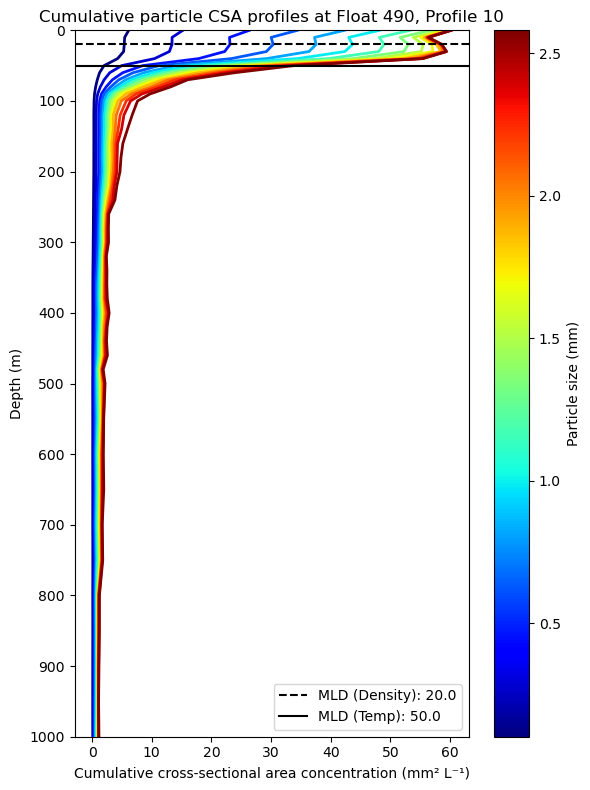

In [ ]:
## OBSERVATIONAL DATA DEPTH PROFILE (DIAGNOSTIC FIGURE) 

# pick profile that will be used as a diagnostic, maybe close to super station or something
# would need to calculate cross-sectional area of particles (method in notebook) for each size class
# then expand that over depth

mid_size = pd.read_excel("UVP_Float_Data.xlsx", sheet_name="UVP_Float_Data").iloc[3:18, 16]     # (size_mid_um)
mid_size.drop_duplicates()
mid_size = mid_size.to_numpy(dtype=float)
mid_size[-1] = 2580

# Choose which float and profile to investigate
UVP6_float = 490
number = 10
profile = f490.p10  # here you can change the float profile, could probably tidy this up more so that when you write your variable name it updates UVP6_float and number automatically but not a good use of time

float_temp = temp_490["P10"]
float_sal = sal_490["P10"]


# Apply mid-size scaling
# shape = (n_sizes, n_depth)
concs = np.array([profile[s] for s in sizes], dtype=float)
circle_scale = np.pi * ((mid_size / 2) ** 2)  # calculate the cross-sectional area of a circle for each mid-size
cross_sectional_area = (concs * circle_scale[:, None]) / 1000000

## calculate mixed layer depth depending on profile
# extract temperature and density from relevant biogeochemical float data
# does that mean binning the temperature and density data to match the particle concentration depth bins?

import gsw
float_temp_CT = gsw.CT_from_t(float_sal, float_temp, depth)
float_density = gsw.rho(float_sal, float_temp_CT, depth) - 1000                  ## look at this as either a) how I calculated density or b) the pressure values I fed into it, is wrong, as density MLD seems to be very shallow
                                                                              ## additionally look at the binning of temperature and density, maybe add a secondary y axis for continous depth to assess more accurately

# reference values = first element
ref_density = float_density[0]
ref_temp = float_temp[0]

# find first index where threshold is met
density_diff = np.abs(float_density - ref_density)
temp_diff = np.abs(float_temp - ref_temp)

MLD_density_idx = np.where(density_diff >= 0.03)[0][0]
MLD_temp_idx = np.where(temp_diff >= 0.2)[0][0]

MLD_density = depth[MLD_density_idx] + 10      # correction for surface? As the array calculates 20 m as 10 m
MLD_temp = depth[MLD_temp_idx] + 10


# Plotting Cumulative stack

fig, ax = plt.subplots(figsize=(6,8))

# cumulative sum across size bins
cumulative = np.cumsum(cross_sectional_area, axis=0)

# create a colour gradient
cmap = plt.cm.jet   # you can change this (plasma, turbo, etc.)
colors = cmap(np.linspace(0, 1, len(sizes/1000)))

# plot each cumulative boundary as a line
for i, s in enumerate(sizes):
    ax.plot(cumulative[i], depth,
            color=colors[i],
            linewidth=2)
    
# Add mixed layer depth
ax.axhline(y = MLD_density, color="black", linestyle="--", label=f"MLD (Density): {MLD_density}")    # as straight line across
ax.axhline(y = MLD_temp, color="black", linestyle="-", label=f"MLD (Temp): {MLD_temp}")    # as straight line across

ax.set_xlabel("Cumulative cross-sectional area concentration (mm² L⁻¹)")
ax.set_ylabel("Depth (m)")
ax.set_ylim(0, 1000)
ax.set_yticks(np.linspace(0, 1000, 11))
ax.set_title(f"Cumulative particle CSA profiles at Float {UVP6_float}, Profile {number}")
ax.legend(loc="lower right")

# Colourbar
norm = plt.Normalize(vmin=min(sizes/1000), vmax=max(sizes/1000))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Particle size (mm)")

ax.invert_yaxis()

plt.tight_layout()
plt.show()
